In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET
import random
import numpy as np

import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

PROJECT_ROOT = Path(".").resolve()
IMAGES_DIR = PROJECT_ROOT / "data" / "raw"
ANN_DIR = PROJECT_ROOT / "data" / "annotations"

CLASSES = ["gate", "obstacle"]
CLASS_TO_ID = {c:i for i,c in enumerate(CLASSES)}
CLASS_TO_ID

2026-03-06 09:04:34.089526: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-06 09:04:34.304330: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-06 09:04:34.306219: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 09:04:35.153341: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


{'gate': 0, 'obstacle': 1}

In [2]:
def read_voc(xml_path: Path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")  # sometimes exists
    size = root.find("size")
    w = int(size.findtext("width"))
    h = int(size.findtext("height"))

    objs = []
    for obj in root.findall("object"):
        label = obj.findtext("name")
        bnd = obj.find("bndbox")
        xmin = int(float(bnd.findtext("xmin")))
        ymin = int(float(bnd.findtext("ymin")))
        xmax = int(float(bnd.findtext("xmax")))
        ymax = int(float(bnd.findtext("ymax")))
        objs.append((label, xmin, ymin, xmax, ymax))

    return filename, (w, h), objs


def find_image_for_xml(xml_path: Path) -> Path:
    # prefer same stem
    candidates = []
    for ext in [".jpg", ".jpeg", ".png"]:
        p = IMAGES_DIR / (xml_path.stem + ext)
        if p.exists():
            candidates.append(p)
    if candidates:
        return candidates[0]

    # fallback: use filename field inside xml
    filename, _, _ = read_voc(xml_path)
    if filename:
        p = IMAGES_DIR / filename
        if p.exists():
            return p

    raise FileNotFoundError(f"Could not find image for {xml_path.name}")


xml_files = sorted(ANN_DIR.glob("*.xml"))
print("XML files:", len(xml_files))

items = []
for xml in xml_files:
    try:
        img_path = find_image_for_xml(xml)
        _, (w, h), objs = read_voc(xml)
        # keep only labels we know
        objs = [o for o in objs if o[0] in CLASS_TO_ID]
        if len(objs) == 0:
            continue
        items.append((img_path, xml, (w,h), objs))
    except Exception as e:
        print("Skipping", xml.name, "->", e)

print("Usable labeled samples:", len(items))
print("Example:", items[0][0].name if items else None)

XML files: 6
Usable labeled samples: 6
Example: 19282699.jpg


In [3]:
def find_image_for_xml(xml_path: Path) -> Path:
    # Prefer same stem
    for ext in [".jpg", ".jpeg", ".png", ".JPG", ".PNG", ".JPEG"]:
        p = IMAGES_DIR / (xml_path.stem + ext)
        if p.exists():
            return p

    # Fallback: use <filename> inside XML if present
    filename, _, _ = read_voc(xml_path)
    if filename:
        p = IMAGES_DIR / filename
        if p.exists():
            return p

    raise FileNotFoundError(f"Could not find image for {xml_path.name}")


xml_files = sorted(ANN_DIR.glob("*.xml"))
print("XML files:", len(xml_files))

items = []
skipped = 0
for xml in xml_files:
    try:
        img_path = find_image_for_xml(xml)
        filename, (w, h), objs = read_voc(xml)

        # keep only known labels
        objs = [o for o in objs if o[0] in CLASS_TO_ID]
        if len(objs) == 0:
            skipped += 1
            continue

        items.append((img_path, xml, (w, h), objs))
    except Exception as e:
        skipped += 1
        print("Skipping:", xml.name, "->", e)

print("Usable labeled samples:", len(items))
print("Skipped:", skipped)
if items:
    print("Example:", items[0][0].name, items[0][1].name, "objs:", len(items[0][3]))

XML files: 6
Usable labeled samples: 6
Skipped: 0
Example: 19282699.jpg 19282699.xml objs: 3


In [4]:
random.shuffle(items)
split = int(0.8 * len(items))

train_items = items[:split]
val_items = items[split:]

print("Train:", len(train_items), "Val:", len(val_items))

Train: 4 Val: 2


In [5]:
def pick_biggest_box(objs):
    best = None
    best_area = -1
    for label, xmin, ymin, xmax, ymax in objs:
        area = (xmax - xmin) * (ymax - ymin)
        if area > best_area:
            best_area = area
            best = (label, xmin, ymin, xmax, ymax)
    return best


def make_simple(rows):
    out = []
    for img_path, xml, (w, h), objs in rows:
        label, xmin, ymin, xmax, ymax = pick_biggest_box(objs)
        out.append((img_path, w, h, label, xmin, ymin, xmax, ymax))
    return out

train_simple = make_simple(train_items)
val_simple = make_simple(val_items)

len(train_simple), len(val_simple)

(4, 2)

In [6]:
IMG_SIZE = 224

def load_example(row):
    img_path, w, h, label, xmin, ymin, xmax, ymax = row

    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"cv2.imread failed: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # normalized box in original image coords
    x1 = xmin / w
    y1 = ymin / h
    x2 = xmax / w
    y2 = ymax / h

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0

    cls = np.int32(CLASS_TO_ID[label])
    box = np.array([x1, y1, x2, y2], dtype=np.float32)
    return img, {"bbox": box, "cls": cls}


def make_dataset(rows, batch=8, shuffle=True):
    X, B, Y = [], [], []
    for r in rows:
        img, target = load_example(r)
        X.append(img)
        B.append(target["bbox"])
        Y.append(target["cls"])

    X = np.stack(X, axis=0)
    B = np.stack(B, axis=0)
    Y = np.array(Y, dtype=np.int32)

    ds = tf.data.Dataset.from_tensor_slices((X, {"bbox": B, "cls": Y}))
    if shuffle and len(X) > 1:
        ds = ds.shuffle(len(X))
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_simple, batch=8, shuffle=True)
val_ds = make_dataset(val_simple, batch=8, shuffle=False)

train_ds

2026-03-06 09:04:49.617442: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-06 09:04:49.618189: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), {'bbox': TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), 'cls': TensorSpec(shape=(None,), dtype=tf.int32, name=None)})>

In [7]:
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg",
)
base.trainable = False  # start frozen

inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inp, training=False)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)

bbox = tf.keras.layers.Dense(4, activation="sigmoid", name="bbox")(x)
cls  = tf.keras.layers.Dense(len(CLASSES), activation="softmax", name="cls")(x)

model = tf.keras.Model(inp, outputs={"bbox": bbox, "cls": cls})
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 mobilenetv2_1.00_224 (Function  (None, 1280)        2257984     ['input_2[0][0]']                
 al)                                                                                              
                                                                                                  
 dense (Dense)                  (None, 256)          327936      ['mobilenetv2_1.00_224[0][0]']   
                                                                                              

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={"bbox": tf.keras.losses.Huber(),
          "cls": tf.keras.losses.SparseCategoricalCrossentropy()},
    metrics={"cls": ["accuracy"]},
)

EPOCHS = 10 if len(train_simple) >= 20 else 5
history = model.fit(train_ds, validation_data=val_ds if len(val_simple) else None, epochs=EPOCHS)


Epoch 1/5


2026-03-06 09:04:56.217927: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype float and shape [4,224,224,3]
	 [[{{node Placeholder/_0}}]]
2026-03-06 09:04:56.218477: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [4,4]
	 [[{{node Placeholder/_1}}]]


1/1 [==============================] - ETA: 0s - loss: 0.7846 - bbox_loss: 0.0389 - cls_loss: 0.7456 - cls_accuracy: 0.5000

2026-03-06 09:04:58.371969: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype int32 and shape [2]
	 [[{{node Placeholder/_2}}]]


1/1 [==============================] - 3s 3s/step - loss: 0.7846 - bbox_loss: 0.0389 - cls_loss: 0.7456 - cls_accuracy: 0.5000 - val_loss: 0.1460 - val_bbox_loss: 0.0634 - val_cls_loss: 0.0827 - val_cls_accuracy: 1.0000
Epoch 2/5
1/1 [==============================] - 0s 84ms/step - loss: 0.0600 - bbox_loss: 0.0198 - cls_loss: 0.0402 - cls_accuracy: 1.0000 - val_loss: 0.0995 - val_bbox_loss: 0.0539 - val_cls_loss: 0.0456 - val_cls_accuracy: 1.0000
Epoch 3/5
1/1 [==============================] - 0s 85ms/step - loss: 0.0256 - bbox_loss: 0.0153 - cls_loss: 0.0103 - cls_accuracy: 1.0000 - val_loss: 0.0659 - val_bbox_loss: 0.0490 - val_cls_loss: 0.0168 - val_cls_accuracy: 1.0000
Epoch 4/5
1/1 [==============================] - 0s 88ms/step - loss: 0.0111 - bbox_loss: 0.0066 - cls_loss: 0.0045 - cls_accuracy: 1.0000 - val_loss: 0.0555 - val_bbox_loss: 0.0493 - val_cls_loss: 0.0062 - val_cls_accuracy: 1.0000
Epoch 5/5
1/1 [==============================] - 0s 83ms/step - loss: 0.0152 - bbox_

Testing on: 33582585.jpg


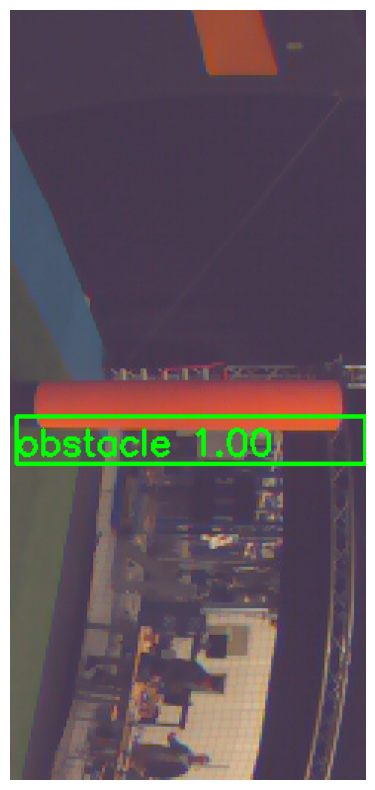

In [9]:
def predict_and_show(image_path: Path):
    img_bgr = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]

    inp_img = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
    pred = model.predict(inp_img[None, ...], verbose=0)

    box = pred["bbox"][0]  # x1,y1,x2,y2
    probs = pred["cls"][0]
    cls_id = int(np.argmax(probs))
    score = float(np.max(probs))
    label = CLASSES[cls_id]

    x1, y1, x2, y2 = int(box[0]*W), int(box[1]*H), int(box[2]*W), int(box[3]*H)

    vis = img_rgb.copy()
    cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(vis, f"{label} {score:.2f}", (x1, max(0, y1-6)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    plt.figure(figsize=(6,10))
    plt.imshow(vis)
    plt.axis("off")
    plt.show()


# choose a random image to test
test_img = random.choice(list(IMAGES_DIR.glob("*.jpg")) + list(IMAGES_DIR.glob("*.png")))
print("Testing on:", test_img.name)
predict_and_show(test_img)